DBSCAN

In [2]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [3]:
#Create and Inspect the Dataset
from sklearn.datasets import make_moons

# Generate two moon-shaped clusters
X, y = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

# Display first 5 rows
df.head()

,Feature_1,Feature_2
0,0.830640,-0.425055
1,0.759684,0.829335
2,1.039113,-0.488126
3,-0.281591,0.969380
4,0.315699,1.111454


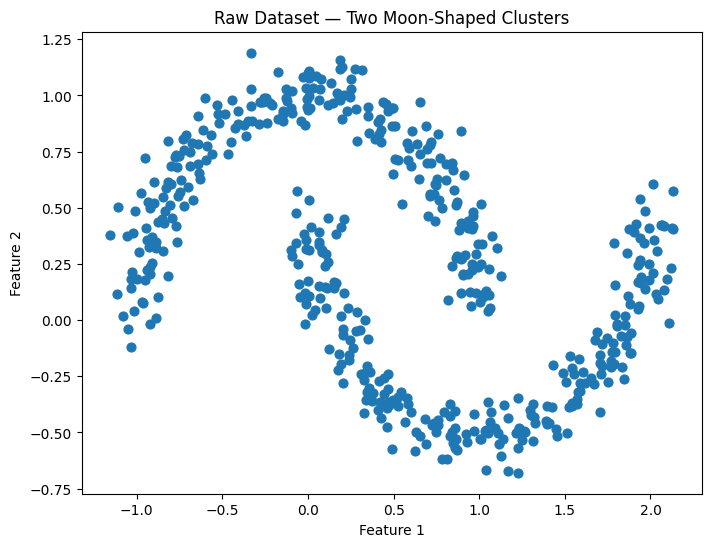

In [4]:
#Visualize the Raw Dataset
plt.figure(figsize=(8, 6))
plt.scatter(
    df['Feature_1'],
    df['Feature_2'],
    s=40
)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Raw Dataset — Two Moon-Shaped Clusters')

plt.show()

In [5]:
#Feature Scaling
# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (500, 2)
Scaled shape: (500, 2)


In [6]:
pd.DataFrame(
    X_scaled,
    columns=['Feature_1', 'Feature_2']
).head()

,Feature_1,Feature_2
0,0.370873,-1.345210
1,0.289497,1.146542
2,0.609962,-1.470496
3,-0.904697,1.424732
4,-0.219690,1.706951


In [7]:
#Apply DBSCAN
# Create DBSCAN model
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

# Fit the model and predict cluster labels
labels = dbscan.fit_predict(X_scaled)

print("Cluster labels:")
print(np.unique(labels))

Cluster labels:
[0 1]


In [8]:
#Count Clusters and Noise
# Number of clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise points
n_noise = list(labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 2
Number of noise points: 0


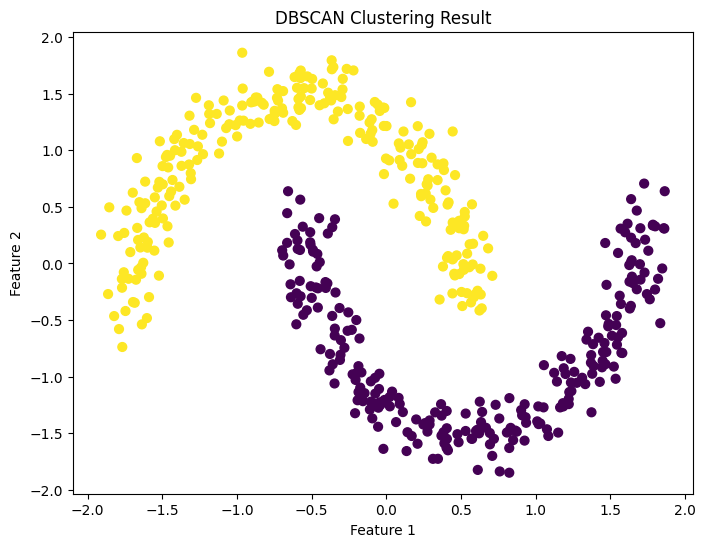

In [9]:
#Visualize DBSCAN Clusters
# Visualize DBSCAN clusters

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    s=40
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN Clustering Result')

plt.show()

In [10]:
#Identify Noise Points
# Identify noise points
noise_points = X_scaled[labels == -1]

print("Number of noise points:", len(noise_points))

Number of noise points: 0


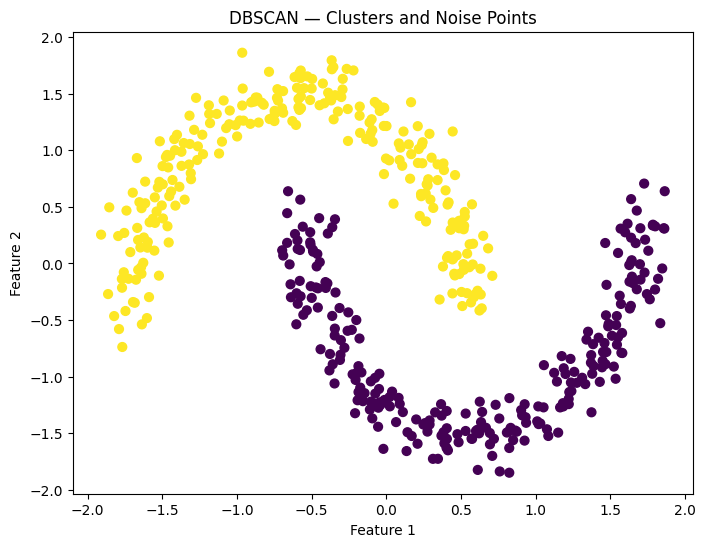

In [11]:
#Visualize Only Noise Points
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    s=40
)

# Highlight noise points
if len(noise_points) > 0:
    plt.scatter(
        noise_points[:, 0],
        noise_points[:, 1],
        s=80,
        marker='x',
        label='Noise'
    )
    plt.legend()

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN — Clusters and Noise Points')

plt.show()

In [12]:
#Experiment with eps
eps_values = [0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    test_labels = model.fit_predict(X_scaled)

    clusters = len(set(test_labels)) - (1 if -1 in test_labels else 0)
    noise = list(test_labels).count(-1)

    print(
        f"eps={eps}: "
        f"clusters={clusters}, "
        f"noise={noise}"
    )

eps=0.15: clusters=4, noise=23
eps=0.2: clusters=2, noise=4
eps=0.25: clusters=2, noise=0
eps=0.3: clusters=2, noise=0
eps=0.4: clusters=2, noise=0
eps=0.5: clusters=1, noise=0


In [13]:
#Experiment with min_samples
min_samples_values = [3, 5, 8, 10, 15]

for min_samples in min_samples_values:
    model = DBSCAN(
        eps=0.3,
        min_samples=min_samples
    )

    test_labels = model.fit_predict(X_scaled)

    clusters = len(set(test_labels)) - (1 if -1 in test_labels else 0)
    noise = list(test_labels).count(-1)

    print(
        f"min_samples={min_samples}: "
        f"clusters={clusters}, "
        f"noise={noise}"
    )

min_samples=3: clusters=2, noise=0
min_samples=5: clusters=2, noise=0
min_samples=8: clusters=2, noise=0
min_samples=10: clusters=2, noise=1
min_samples=15: clusters=2, noise=2


In [14]:
#Final DBSCAN Model
final_dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

final_labels = final_dbscan.fit_predict(X_scaled)

print("Final number of clusters:",
      len(set(final_labels)) - (1 if -1 in final_labels else 0))

print("Final number of noise points:",
      list(final_labels).count(-1))

Final number of clusters: 2
Final number of noise points: 0


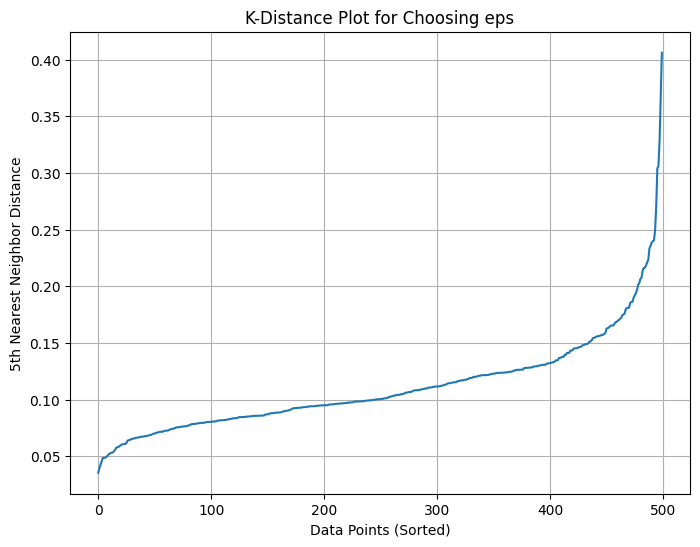

In [15]:
#K-Distance Plot for Choosing eps
from sklearn.neighbors import NearestNeighbors

# Set k = min_samples
k = 5

# Find the k nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

# Take distance to the kth nearest neighbor
k_distances = distances[:, -1]

# Sort distances
k_distances = np.sort(k_distances)

# Plot k-distance curve
plt.figure(figsize=(8, 6))

plt.plot(k_distances)

plt.xlabel('Data Points (Sorted)')
plt.ylabel(f'{k}th Nearest Neighbor Distance')
plt.title('K-Distance Plot for Choosing eps')

plt.grid()
plt.show()

In [16]:
#Test the Selected eps
eps = 0.3

model = DBSCAN(
    eps=eps,
    min_samples=5
)

labels = model.fit_predict(X_scaled)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = list(labels).count(-1)

print("Selected eps:", eps)
print("Clusters:", clusters)
print("Noise points:", noise)

Selected eps: 0.3
Clusters: 2
Noise points: 0


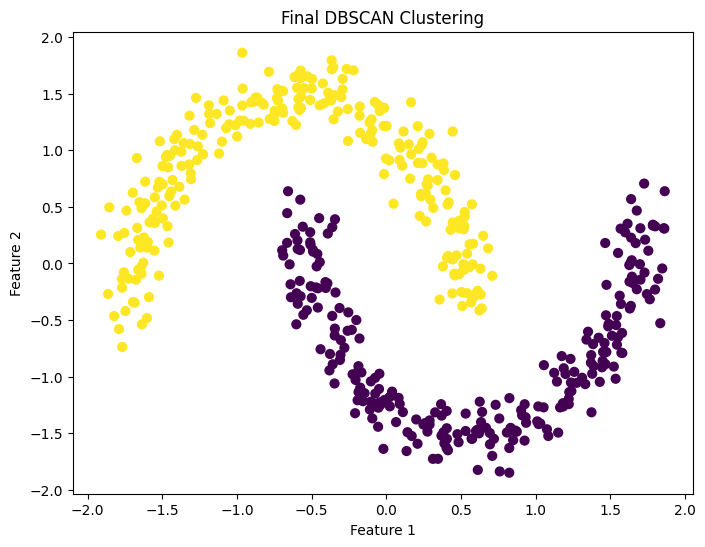

In [18]:
#Final Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    s=40
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Final DBSCAN Clustering')

plt.show()
